# Laboratório Quantitativo 01: Validação da Esteira de Dados e Modelo VAR
 Este notebook valida o funcionamento integrado da `IndexFactory`, do motor de séries temporais `MacroPredictorEngine` e do recalculador contratual de passivos `PassivoCalculatorEngine`.

In [14]:
import sys
import os

# Sobe um nível (de /notebook para a raiz do projeto) e adiciona ao path do Python
raiz_projeto = os.path.abspath(os.path.join(os.getcwd(), ".."))
if raiz_projeto not in sys.path:
    sys.path.append(raiz_projeto)

# Agora o import vai funcionar perfeitamente
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.simulation.macro_models import MacroPredictorEngine, PredictorConfig
from src.simulation.index_factory import IndexFactory

# Configurações visuais para os plots das bandas de estresse
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

import warnings
from statsmodels.tools.sm_exceptions import ValueWarning
warnings.simplefilter("ignore", category=ValueWarning)

In [15]:
# Carrega a matriz unificada usando a fábrica adaptada
caminho_csv = "../data/dataset_macro.csv"
df_completo = IndexFactory.ler_matriz_unificada(caminho_csv)

# Aplica o corte metodológico acordado (Pós-Plano Real)
df_analise = df_completo[df_completo.index >= '1994-08-01'].copy()

# Criamos uma cópia defensiva para evitar alterações na base bruta original
df_analise_corrigido = df_analise.copy()

# Localiza as colunas dinamicamente para evitar quebras por pequenas variações de string
colunas_brutas = list(df_analise_corrigido.columns)
coluna_ipca = [c for c in colunas_brutas if "IPCA" in c or "433" in c][0]
coluna_igpm = [c for c in colunas_brutas if "IGP-M" in c or "200045" in c][0]
coluna_selic = [c for c in colunas_brutas if "Selic" in c or "4390" in c][0]

# --- TRATAMENTO CRUCIAL DO IGP-M ---
# Transforma o número-índice acumulado (ex: 100 -> 500) em variação percentual mensal (taxa %)
df_analise_corrigido[coluna_igpm] = pd.to_numeric(df_analise_corrigido[coluna_igpm], errors='coerce').pct_change() * 100

# Força a conversão numérica das demais variáveis para blindar contra strings indesejadas
df_analise_corrigido[coluna_ipca] = pd.to_numeric(df_analise_corrigido[coluna_ipca], errors='coerce')
df_analise_corrigido[coluna_selic] = pd.to_numeric(df_analise_corrigido[coluna_selic], errors='coerce')

# Remove as linhas remanescentes com nulos geradas pelo lag do pct_change
df_analise_corrigido = df_analise_corrigido.dropna()

# Inicializa e ajusta o motor com os dados normalizados
config = PredictorConfig(max_lags=3, horizonte_projeção_meses=36, significancia_banda=0.05)
engine = MacroPredictorEngine(config=config)
colunas_validadas = engine.selecionar_e_ajustar_modelo(df_analise_corrigido)

print("🎯 Escala do IGP-M ajustada com sucesso para Variação Mensal (%)!")
print(f"✅ Modelo VAR ajustado dinamicamente com {engine.lags_otimos} lag(s) via critério AIC.")

🎯 Escala do IGP-M ajustada com sucesso para Variação Mensal (%)!
✅ Modelo VAR ajustado dinamicamente com 2 lag(s) via critério AIC.


In [16]:
print("📋 --- DIAGNÓSTICO DO DATAFRAME DE ANÁLISE CORRIGIDO ---")
print(f"Formato da Matriz: {df_analise_corrigido.shape[0]} meses x {df_analise_corrigido.shape[1]} colunas\n")

# Filtra o dataframe para exibir estritamente as colunas tratadas da nossa cesta macro
cesta_macro_colunas = [coluna_ipca, coluna_igpm, coluna_selic]
df_diagnostico = df_analise_corrigido[cesta_macro_colunas]

print("📊 Tipos de Dados e Nulos por Coluna:")
display(df_diagnostico.info())

print("\n📈 Primeiras 5 linhas do Dataset (Head) - Escala de Variação Mensal %:")
display(df_diagnostico.head())

print("\n📉 Estatísticas Descritivas Consolidadas:")
display(df_diagnostico.describe())

📋 --- DIAGNÓSTICO DO DATAFRAME DE ANÁLISE CORRIGIDO ---
Formato da Matriz: 359 meses x 9 colunas

📊 Tipos de Dados e Nulos por Coluna:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 359 entries, 1996-07-01 to 2026-05-01
Data columns (total 3 columns):
 #   Column                                                                      Non-Null Count  Dtype  
---  ------                                                                      --------------  -----  
 0   433 - Índice nacional de preços ao consumidor-amplo (IPCA) - Var. % mensal  359 non-null    float64
 1   Índice Geral de Preços - IGP-M(200045)                                      359 non-null    float64
 2   4390 - Taxa de juros - Selic acumulada no mês - % a.m.                      359 non-null    float64
dtypes: float64(3)
memory usage: 11.2 KB


None


📈 Primeiras 5 linhas do Dataset (Head) - Escala de Variação Mensal %:


,433 - Índice nacional de preços ao consumidor-amplo (IPCA) - Var. % mensal,Índice Geral de Preços - IGP-M(200045),4390 - Taxa de juros - Selic acumulada no mês - % a.m.
Data,,,
1996-07-01,1.11,1.345049,1.93
1996-08-01,0.44,0.280753,1.97
1996-09-01,0.15,0.101058,1.90
1996-10-01,0.30,0.191442,1.86
1996-11-01,0.32,0.197047,1.80



📉 Estatísticas Descritivas Consolidadas:


,433 - Índice nacional de preços ao consumidor-amplo (IPCA) - Var. % mensal,Índice Geral de Preços - IGP-M(200045),4390 - Taxa de juros - Selic acumulada no mês - % a.m.
count,359.000000,359.000000,359.000000
mean,0.489805,0.628855,1.079081
std,0.392838,0.906116,0.500848
min,-0.680000,-1.929875,0.130000
25%,0.250000,0.146080,0.790000
50%,0.440000,0.506717,1.020000
75%,0.670000,0.976869,1.340000
max,3.020000,5.189787,3.330000


In [17]:
from statsmodels.tsa.api import VAR
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Mapeia as variáveis para o loop estruturado
alvos_grid = {
    "IPCA": coluna_ipca,
    "IGP-M": coluna_igpm,
    "SELIC": coluna_selic
}

# Lista contendo estritamente as colunas que o motor do VAR deve processar
colunas_selecionadas = [coluna_ipca, coluna_igpm, coluna_selic]

lista_alphas = [0.30, 0.25, 0.20, 0.15, 0.10, 0.05, 0.01]
resultados_grid = []
meses_teste = 36

print("⏳ Iniciando simulação Walk-Forward para o Grid de Significâncias (Amostra Móvel)...")

for alpha in lista_alphas:
    for apelido, nome_coluna in alvos_grid.items():
        # Pega o índice correto baseado apenas na sub-matriz que será enviada ao VAR
        idx_alvo = colunas_selecionadas.index(nome_coluna)
        
        total_pontos = 0
        v_var = 0
        v_sarima = 0
        amp_var_acum = []
        amp_sarima_acum = []
        
        for i in range(meses_teste - 3):
            df_treino_movel = df_analise_corrigido.iloc[:-(meses_teste - i)].copy()
            if len(df_treino_movel) < 50:
                continue
            
            reais = df_analise_corrigido.iloc[len(df_treino_movel):len(df_treino_movel)+3][nome_coluna].values
            
            # --- BLINDAGEM DO VAR ---
            # Filtramos estritamente as colunas numéricas de interesse para evitar "dtype of object"
            df_var_input = df_treino_movel[colunas_selecionadas].astype(float)
            
            model_var_temp = VAR(df_var_input)
            res_var_temp = model_var_temp.fit(maxlags=engine.lags_otimos)
            stderr_var = res_var_temp.forecast_interval(df_var_input.values[-engine.lags_otimos:], steps=3, alpha=alpha)
            
            lim_inf_v, lim_sup_v = stderr_var[1][:, idx_alvo], stderr_var[2][:, idx_alvo]
            amp_var_acum.extend(lim_sup_v - lim_inf_v)
            
            # 2. Avaliação do SARIMA Univariado
            serie_sarima = pd.to_numeric(df_treino_movel[nome_coluna], errors='coerce').dropna().astype(float)
            model_sarima_temp = SARIMAX(serie_sarima, order=(1,1,1), seasonal_order=(1,0,0,12), enforce_stationarity=False)
            res_sarima_temp = model_sarima_temp.fit(disp=False)
            proj_sarima_temp = res_sarima_temp.get_forecast(steps=3)
            intervalo_sarima = proj_sarima_temp.conf_int(alpha=alpha)
            
            lim_inf_s = intervalo_sarima.iloc[:, 0].values
            lim_sup_s = intervalo_sarima.iloc[:, 1].values
            amp_sarima_acum.extend(lim_sup_s - lim_inf_s)
            
            # Contabilização de Violações de Cauda
            for r, inf_v, sup_v, inf_s, sup_s in zip(reais, lim_inf_v, lim_sup_v, lim_inf_s, lim_sup_s):
                total_pontos += 1
                if r > sup_v or r < inf_v: v_var += 1
                if r > sup_s or r < inf_s: v_sarima += 1
                
        resultados_grid.append({
            "Variável": apelido,
            "Significância Teórica (α)": f"{alpha*100:.0f}%",
            "Confiança": f"{(1-alpha)*100:.0f}%",
            "VAR Taxa Violação": v_var / total_pontos if total_pontos > 0 else 0,
            "VAR Amplitude Média": np.mean(amp_var_acum) if amp_var_acum else 0,
            "SARIMA Taxa Violação": v_sarima / total_pontos if total_pontos > 0 else 0,
            "SARIMA Amplitude Média": np.mean(amp_sarima_acum) if amp_sarima_acum else 0
        })

# Consolidação do Relatório Executivo
df_grid_final = pd.DataFrame(resultados_grid)
df_exposicao = df_grid_final.copy()
df_exposicao["VAR Taxa Violação"] = df_exposicao["VAR Taxa Violação"].map(lambda x: f"{x*100:.2f}%")
df_exposicao["SARIMA Taxa Violação"] = df_exposicao["SARIMA Taxa Violação"].map(lambda x: f"{x*100:.2f}%")
df_exposicao["VAR Amplitude Média"] = df_exposicao["VAR Amplitude Média"].map(lambda x: f"{x:.4f} p.p.")
df_exposicao["SARIMA Amplitude Média"] = df_exposicao["SARIMA Amplitude Média"].map(lambda x: f"{x:.4f} p.p.")

print("\n📊 --- RELATÓRIO COMPARATIVO DE RISK MANAGEMENT DE CAUDA ---")
display(df_exposicao.sort_values(by=["Variável", "Confiança"], ascending=[True, True]))

⏳ Iniciando simulação Walk-Forward para o Grid de Significâncias (Amostra Móvel)...


/home/marth/Documentos/caprisk-engine/.conda/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/marth/Documentos/caprisk-engine/.conda/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/marth/Documentos/caprisk-engine/.conda/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/marth/Documentos/caprisk-engine/.conda/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood o


📊 --- RELATÓRIO COMPARATIVO DE RISK MANAGEMENT DE CAUDA ---


,Variável,Significância Teórica (α),Confiança,VAR Taxa Violação,VAR Amplitude Média,SARIMA Taxa Violação,SARIMA Amplitude Média
1,IGP-M,30%,70%,29.29%,1.5752 p.p.,28.28%,1.5871 p.p.
4,IGP-M,25%,75%,22.22%,1.7483 p.p.,19.19%,1.7615 p.p.
7,IGP-M,20%,80%,16.16%,1.9478 p.p.,15.15%,1.9624 p.p.
10,IGP-M,15%,85%,10.10%,2.1879 p.p.,9.09%,2.2043 p.p.
13,IGP-M,10%,90%,6.06%,2.4999 p.p.,6.06%,2.5187 p.p.
16,IGP-M,5%,95%,5.05%,2.9788 p.p.,5.05%,3.0013 p.p.
19,IGP-M,1%,99%,1.01%,3.9149 p.p.,1.01%,3.9443 p.p.
0,IPCA,30%,70%,17.17%,0.7287 p.p.,18.18%,0.7328 p.p.
3,IPCA,25%,75%,14.14%,0.8088 p.p.,11.11%,0.8134 p.p.
6,IPCA,20%,80%,7.07%,0.9011 p.p.,7.07%,0.9062 p.p.


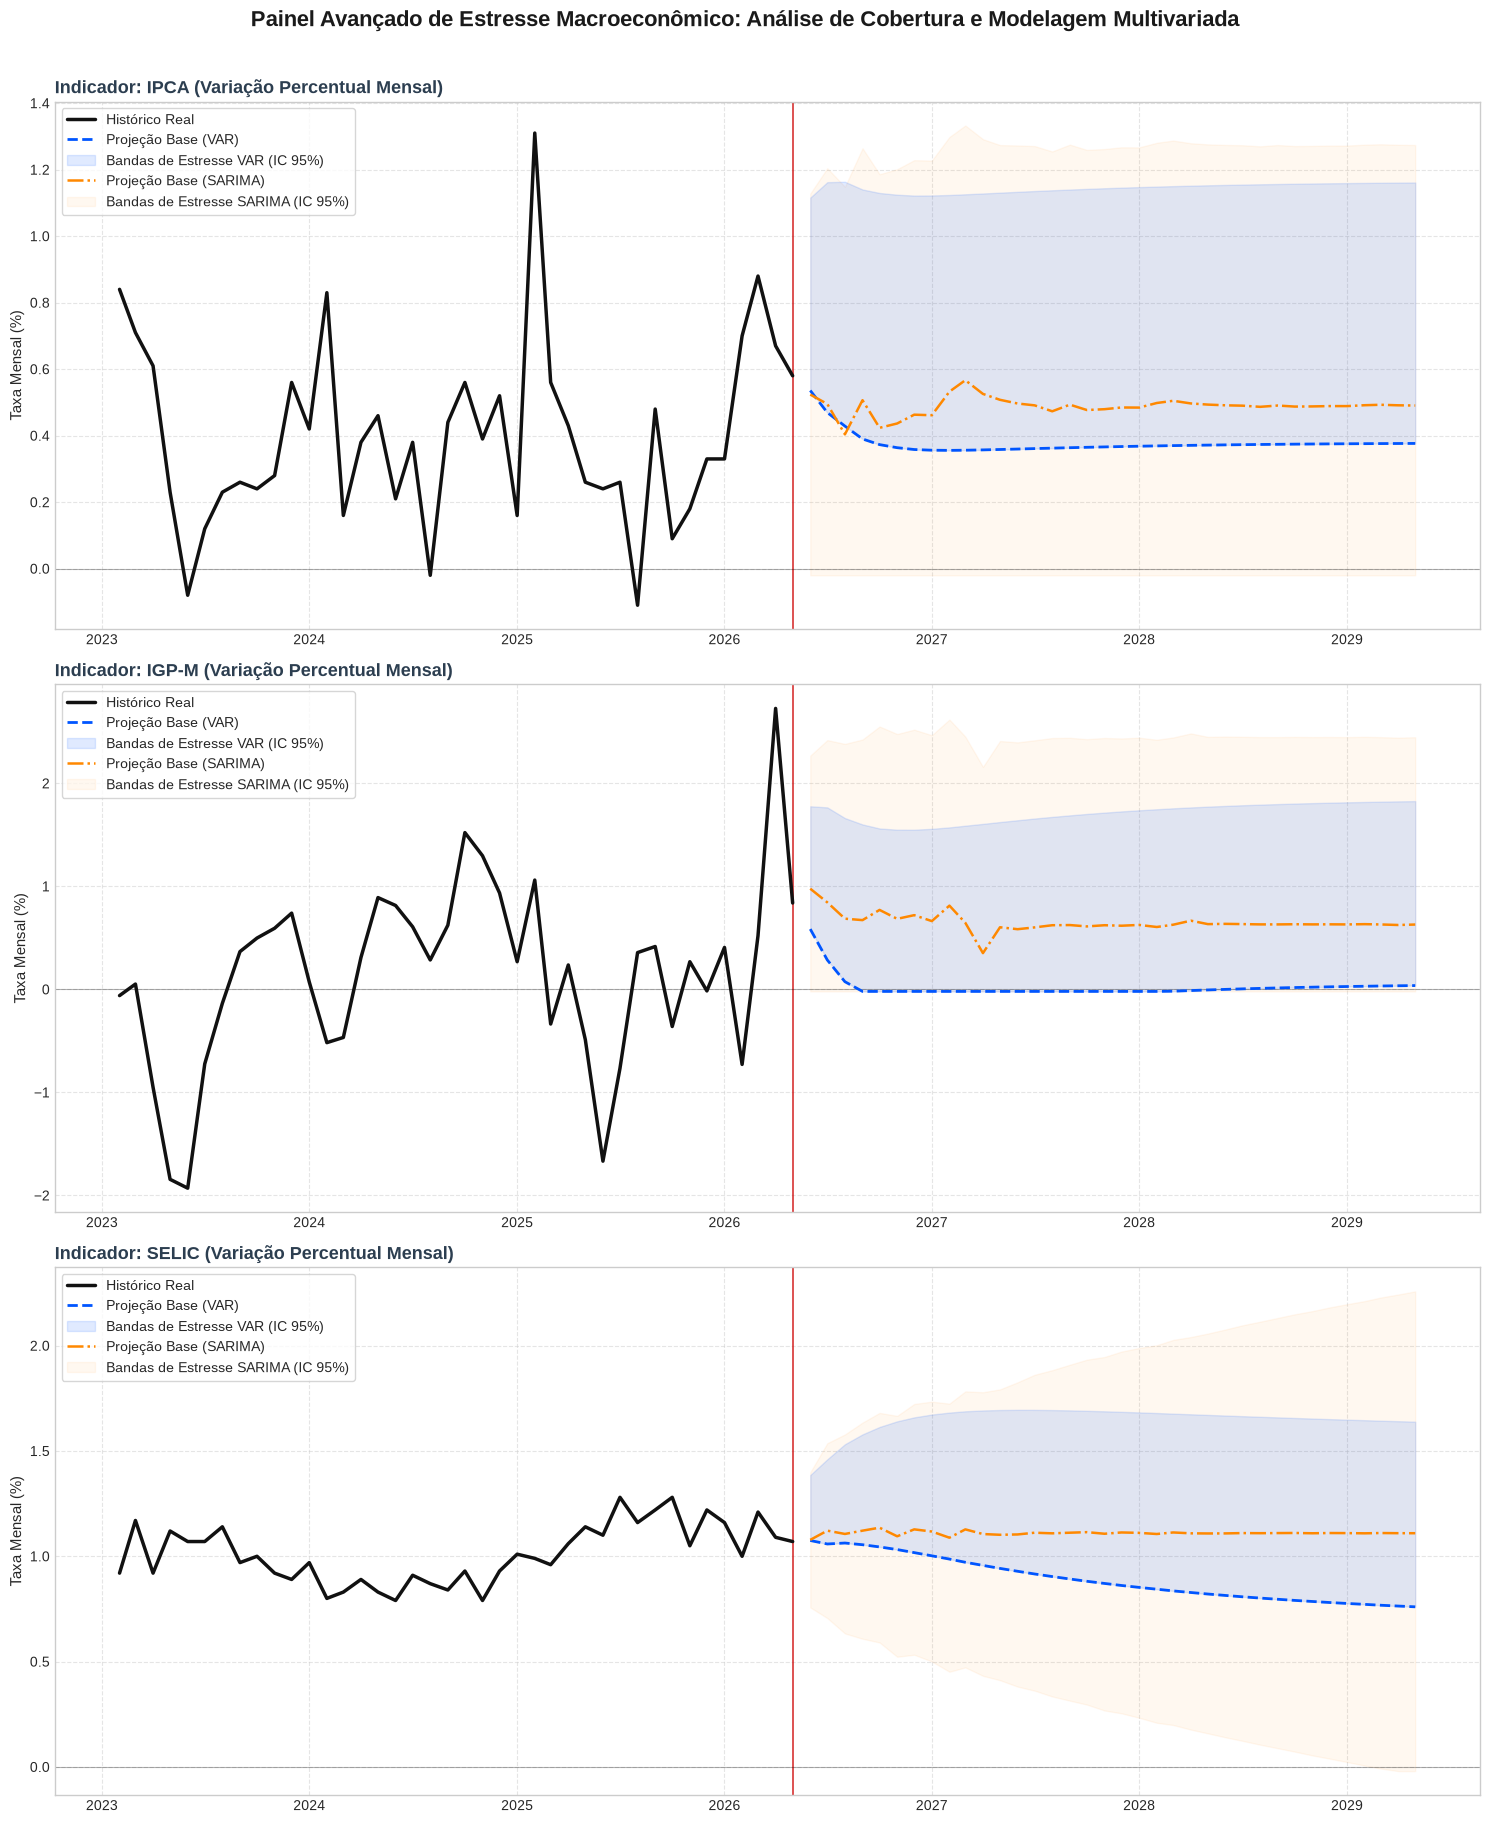

In [18]:
# Gera os cenários futuros consolidados a partir do último ponto estável observado
cenarios_var_futuro = engine.gerar_projeções_estresse(df_analise_corrigido)

fig, axes = plt.subplots(3, 1, figsize=(15, 18), dpi=100)

for idx, (apelido, nome_coluna) in enumerate(alvos_grid.items()):
    ax = axes[idx]
    
    # Isola o histórico de cauda recente para dar profundidade visual (últimos 40 meses)
    hist_plot = pd.to_numeric(df_analise_corrigido[nome_coluna].tail(40), errors='coerce').dropna()
    
    # Estruturas Futuras VAR (Azul)
    df_var_f = cenarios_var_futuro[nome_coluna]
    var_b = pd.to_numeric(df_var_f["CENARIO_BASE"], errors='coerce').astype(float)
    var_s = pd.to_numeric(df_var_f["CENARIO_ESTRESSE_SUPERIOR"], errors='coerce').astype(float)
    var_i = pd.to_numeric(df_var_f["CENARIO_ESTRESSE_INFERIOR"], errors='coerce').astype(float)
    
    # Estruturas Futuras SARIMA (Laranja)
    df_sarima_f = engine.gerar_projeções_benchmark_sarima(df_analise_corrigido, coluna_alvo=nome_coluna)
    sar_b = pd.to_numeric(df_sarima_f["SARIMA_BASE"], errors='coerce').astype(float)
    sar_s = pd.to_numeric(df_sarima_f["SARIMA_ESTRESSE_SUPERIOR"], errors='coerce').astype(float)
    sar_i = pd.to_numeric(df_sarima_f["SARIMA_ESTRESSE_INFERIOR"], errors='coerce').astype(float)
    
    # --- PLOTS LINEARES ---
    ax.plot(hist_plot.index, hist_plot.values, color="#111111", linewidth=2.5, label="Histórico Real", zorder=4)
    
    # Camada VAR
    ax.plot(var_b.index, var_b.values, color="#0055ff", linestyle="--", linewidth=2, label="Projeção Base (VAR)", zorder=3)
    ax.fill_between(var_b.index, var_i.values, var_s.values, color="#0055ff", alpha=0.12, label="Bandas de Estresse VAR (IC 95%)", zorder=2)
    
    # Camada SARIMA
    ax.plot(sar_b.index, sar_b.values, color="#ff8800", linestyle="-.", linewidth=1.8, label="Projeção Base (SARIMA)", zorder=3)
    ax.fill_between(sar_b.index, sar_i.values, sar_s.values, color="#ff8800", alpha=0.06, label="Bandas de Estresse SARIMA (IC 95%)", zorder=1)
    
    # --- FORMATACAO EXECUTIVA ---
    ax.axvline(x=hist_plot.index[-1], color="#cc0000", linestyle="-", linewidth=1.2, alpha=0.8)
    ax.set_title(f"Indicador: {apelido} (Variação Percentual Mensal)", fontsize=13, fontweight='bold', color='#2c3e50', loc='left')
    ax.set_ylabel("Taxa Mensal (%)", fontsize=11)
    ax.grid(True, linestyle="--", alpha=0.5, color="#cccccc")
    ax.axhline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.3)
    ax.legend(loc="upper left", frameon=True, facecolor="white", fontsize=10)
    
    # Libera os eixos para o Matplotlib recalcular a geometria linear sem sobreposição
    ax.relim()
    ax.autoscale_view()

plt.suptitle("Painel Avançado de Estresse Macroeconômico: Análise de Cobertura e Modelagem Multivariada", fontsize=16, fontweight='bold', y=1.01, color='#1a1a1a')
plt.tight_layout()
plt.show()